In [1]:
"""
Coupled Map Lattice (CML) on a 1D Ring
=======================================
Each of N sites on a ring evolves via a local chaotic map (logistic map)
coupled symmetrically to its two nearest neighbours.

Update rule (Kaneko 1984):
  x_i(t+1) = (1 - ε) * f(x_i(t))
            + (ε/2) * [f(x_{i-1}(t)) + f(x_{i+1}(t))]

where f(x) = r * x * (1 - x)  (logistic map)
and periodic (ring) boundary conditions: x_{-1} = x_{N-1}, x_N = x_0
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [2]:
# ── Local map ────────────────────────────────────────────────────────────────

def logistic(x: np.ndarray, r: float = 4.0) -> np.ndarray:
    """Logistic map  f(x) = r·x·(1-x)."""
    return r * x * (1.0 - x)


# ── CML step ─────────────────────────────────────────────────────────────────

def cml_step(x: np.ndarray, epsilon: float, r: float = 4.0) -> np.ndarray:
    """
    Advance the lattice by one time step using the diffusive CML scheme.

    Parameters
    ----------
    x       : current state vector, shape (N,)
    epsilon : coupling strength  (0 = uncoupled, 1 = fully diffusive)
    r       : logistic map parameter

    Returns
    -------
    x_new   : updated state vector, shape (N,)
    """
    fx = logistic(x, r)
    # periodic neighbours via np.roll (ring boundary conditions)
    x_new = (1.0 - epsilon) * fx \
          + (epsilon / 2.0) * (np.roll(fx, 1) + np.roll(fx, -1))
    return x_new


In [6]:
# ── Simulation ────────────────────────────────────────────────────────────────

def simulate(
    N: int       = 100,
    T: int       = 100,
    epsilon: float = 0.3,
    r: float     = 4.0,
    seed: int    = 42,
) -> np.ndarray:
    """
    Run the CML for T time steps on a ring of N sites.

    Returns
    -------
    history : array of shape (T+1, N) — full space-time trajectory
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(0.0, 1.0, size=N)   # random initial condition

    history = np.empty((T + 1, N))
    history[0] = x

    for t in range(T):
        x = cml_step(x, epsilon, r)
        history[t + 1] = x

    return history


In [10]:
def plot_results(history: np.ndarray, epsilon: float, r: float) -> None:
    N, T = history.shape[1], history.shape[0] - 1
 
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(
        f"Coupled Map Lattice — 1D Ring\n"
        f"N = {N} sites, T = {T} steps,  ε = {epsilon},  r = {r}",
        fontsize=13, fontweight="bold"
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
 
    # ── 1. Space-time diagram (heat map) ─────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    im = ax1.imshow(
        history.T,             # shape (N, T+1) — sites on y-axis, time on x
        aspect="auto",
        origin="lower",
        cmap="inferno",
        vmin=0, vmax=1,
        interpolation="nearest",
    )
    ax1.set_xlabel("Time step  t", fontsize=11)
    ax1.set_ylabel("Site  i", fontsize=11)
    ax1.set_title("Space-time diagram  x_i(t)", fontsize=11)
    fig.colorbar(im, ax=ax1, label="x", pad=0.01)
 
    # ── 2. Snapshot at final time ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(history[-1], "o-", ms=3, lw=0.8, color="steelblue")
    ax2.set_xlim(0, N - 1)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("Site  i", fontsize=11)
    ax2.set_ylabel("x_i", fontsize=11)
    ax2.set_title(f"Snapshot at t = {T}", fontsize=11)
    ax2.grid(alpha=0.3)
 
    # ── 3. Time series of three representative sites ──────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    sites = [0, N // 4, N // 2]
    colors = ["royalblue", "crimson", "seagreen"]
    for s, c in zip(sites, colors):
        ax3.plot(history[:, s], lw=0.9, color=c, label=f"site {s}")
    ax3.set_xlim(0, T)
    ax3.set_ylim(0, 1)
    ax3.set_xlabel("Time step  t", fontsize=11)
    ax3.set_ylabel("x_i(t)", fontsize=11)
    ax3.set_title("Time series — selected sites", fontsize=11)
    ax3.legend(fontsize=9, loc="upper right")
    ax3.grid(alpha=0.3)
 
    out_path = OUT_DIR / "cml_1d_ring.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure saved → {out_path}")




Running CML: N=64, T=300, ε=0.3, r=4.0
Final state — mean: 0.6330, std: 0.2708


NameError: name 'OUT_DIR' is not defined

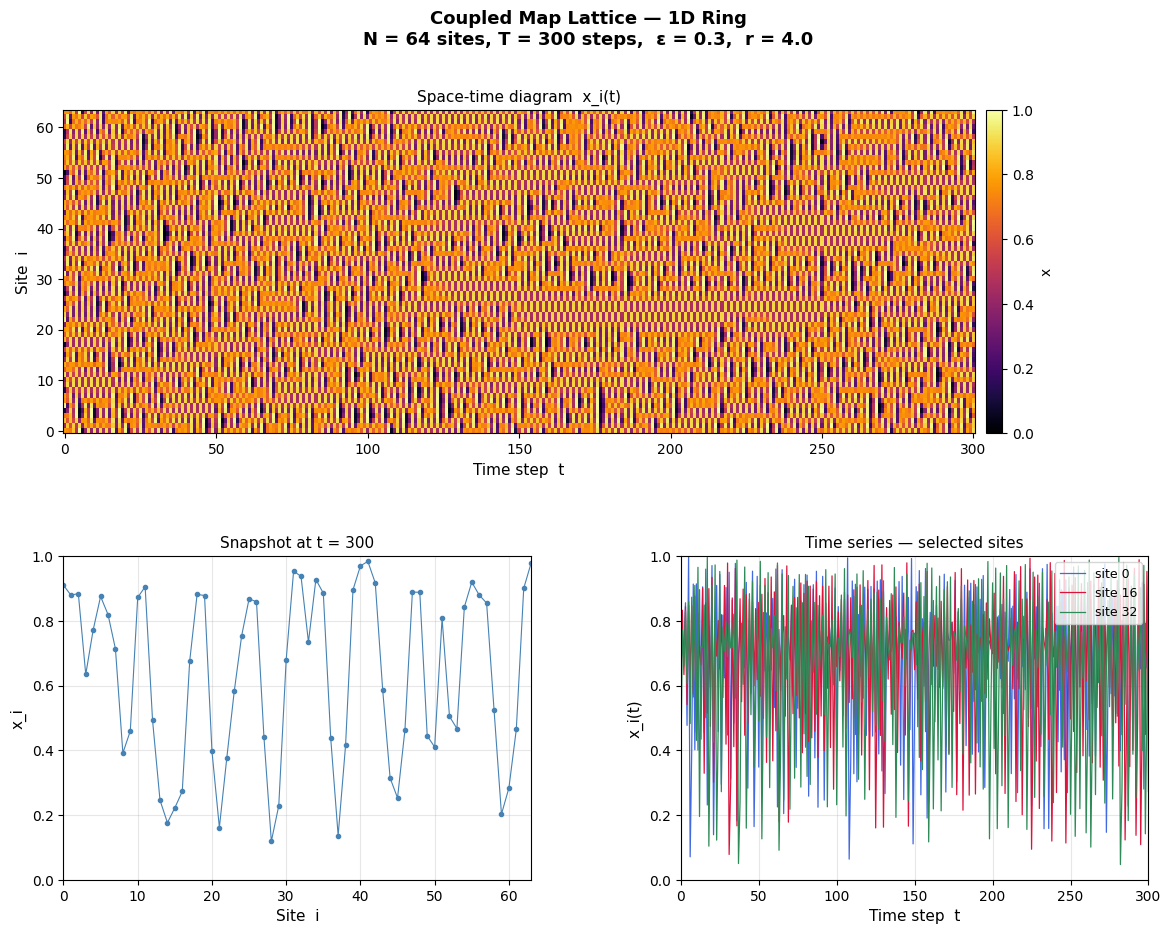

In [11]:
# ── Coupling-strength sweep ───────────────────────────────────────────────────
 
def sweep_epsilon(
    epsilons: list = [0.0, 0.1, 0.3, 0.5, 0.8],
    N: int  = 64,
    T: int  = 200,
    r: float = 4.0,
    seed: int = 7,
) -> None:
    """Plot space-time diagrams for several coupling strengths side by side."""
    n = len(epsilons)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 5), sharey=True)
    fig.suptitle(
        f"Effect of coupling strength ε  (N={N}, T={T}, r={r})",
        fontsize=12, fontweight="bold"
    )
 
    for ax, eps in zip(axes, epsilons):
        hist = simulate(N=N, T=T, epsilon=eps, r=r, seed=seed)
        ax.imshow(
            hist.T, aspect="auto", origin="lower",
            cmap="inferno", vmin=0, vmax=1, interpolation="nearest"
        )
        ax.set_title(f"ε = {eps}", fontsize=10)
        ax.set_xlabel("t")
        if ax is axes[0]:
            ax.set_ylabel("Site i")
 
    plt.tight_layout()
    out_path = OUT_DIR / "cml_sweep_epsilon.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Sweep figure saved → {out_path}")
 
 
# ── Entry point ───────────────────────────────────────────────────────────────
 
if __name__ == "__main__":
    # --- Main simulation ---
    N       = 64      # number of lattice sites
    T       = 300     # number of time steps
    epsilon = 0.3     # coupling strength   (try 0.0 – 1.0)
    r       = 4.0     # logistic map parameter (chaos onset at r > 3.57)
 
    print(f"Running CML: N={N}, T={T}, ε={epsilon}, r={r}")
    history = simulate(N=N, T=T, epsilon=epsilon, r=r)
 
    # Spatial mean and std at last step
    snap = history[-1]
    print(f"Final state — mean: {snap.mean():.4f}, std: {snap.std():.4f}")
 
    plot_results(history, epsilon=epsilon, r=r)
 
    # --- Coupling sweep ---
    sweep_epsilon(epsilons=[0.0, 0.1, 0.3, 0.5, 0.8], N=N, T=200, r=r)